<h1><center>🧠 Homework №1 — BERT for Aspect-Based Sentiment Classification

*Natural Language Processing Course, HSE 2026*

This homework is designed as a hands-on, research-style assignment. You
are expected not only to train models, but also to make methodological
decisions, justify them, and analyze results critically (*this will be taken into account when grading your assignment*) — like an ML
engineer or NLP researcher.

This homework **is based on the materials from the Webinar 2** - take a look at the notebook from that class as it might be really helpful when completing this assignment.

<p align="center">
  <img src="https://www.philschmid.de/static/blog/bert-text-classification-in-a-different-language/meme.png" width="60%">
</p>

### 📥 General Rules and Submission Guidelines

1. Copying code from external sources (**including using LLMs**) without explicit citation is strictly prohibited and will result in 0 points for the entire assignment. If you consult any resources or AI tools, you must clearly state this in a separate Markdown cell. If suspected of this, you might be asked to explain your code to the grader and answer their questions during a separate session to avoid the mentioned penalty.
2. All results must be fully **reproducible**. You are required to use `set_seed` everywhere so that the grader can obtain the same results when rerunning your notebook.
3. The notebook must run from top to bottom without errors. Submissions that fail to execute sequentially will not be accepted.
4. You must satisfy all requirements in each task to receive full credit. Partial completion may lead to partial scoring.
5. Do not modify the original notebook structure or provided Markdown cells. You are only allowed to write code in the sections marked `# TODO: your code here`. Any explanations, interpretations, or additional comments must be placed **in separate Markdown cells**. If you choose to do so, leave an explanation as to what and why was changed.
6. The final submission must be a completed `.ipynb` Jupyter Notebook. You may conduct your experiments in Jupyter Notebook, VS Code, or Google Colab — whichever environment you prefer.

### 🎯 Learning Objectives

By completing this homework, you will:
- Work with a realistic, noisy text dataset.
- Perform careful data preprocessing and label engineering.
- Fine-tune multiple encoder-based transformer models.
- Use validation loss for model selection (early stopping).
- Conduct basic hyperparameter tuning.
- Log your results.
- Build ablation tables and compare experimental settings.
- Interpret results obtained through conducted experiments.

Without any further ado, let's get started. Good luck, and may the odds be ever in your favor!

### 🔧 Environment Setup

Loading necessary libraries. If you need anything else, feel free to add more libraries and dependencies.

In [1]:
!pip install 'transformers[torch]' datasets evaluate optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 19.7 MB/s eta 0:00:00


In [2]:
!pip install datasets

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from datasets import Dataset
import evaluate
import optuna
import random


# TODO: your code here
# Проверка: все библиотеки подключены, seed задан выше
print('PyTorch:', torch.__version__)


PyTorch: 2.10.0+cu128


In [4]:
if not torch.cuda.is_available():
    print("Warning: training will be slow without GPU!")

In [5]:
def set_seed(seed):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1337)

In [ ]:
# BOOTSTRAP
from google.colab import drive
import os
import shutil

drive.mount("/content/drive")

SRC_DIR = "/content/drive/MyDrive/nlp_hw1"
DST_DIR = "/content"
files = ["results_part2.csv", "best_hparams_part3.json", "results_part3_final.csv", "results_part4_10class.csv"]
for f in files:
    src = os.path.join(SRC_DIR, f)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(DST_DIR, f))
        print(f"{f} [OK restored]")
    else:
        print(f"{f} [-- not found]")

### 🗂️ **Part №1. Data Preparation. ($1$ point)**

In this assignment, we're going to be work with the dataset containing reviews on restaurants. The dataset can be downloaded from [here](https://drive.google.com/file/d/19qXNsW-gc_H4ufAt0JREzszKzjKkh170/view).

In this part of the assignment, you will prepare the raw restaurant reviews dataset for model training. The goal is to obtain clean text data, a well-defined target variable, and reproducible train/validation/test splits.

**1.1. Loading and inspecting data ($0.25$ points)**

First, create a code cell that:
- loads the .jsonl file,
- prints basic statistics (size, columns, example rows),
- briefly comments on what you see.

In [6]:
!wget -O restaurants_reviews.jsonl \
"https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT"

--2026-02-24 08:38:52--  https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT
Resolving drive.google.com (drive.google.com)... 74.125.199.101, 74.125.199.113, 74.125.199.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.199.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download [following]
--2026-02-24 08:38:52--  https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.163.132, 2607:f8b0:400e:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.163.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80131991 (76M) [application/octet-stream]
Saving to: ‘restaurants_reviews.jsonl’

restaurants_reviews 100%[===================>]  76.

In [7]:
df = pd.read_json('restaurants_reviews.jsonl', lines=True)
df

,review_id,general,food,interior,service,text
0,0,0,10,10,10,Вытянули меня сегодня в город и раз уж была в ...
1,1,0,9,10,9,проводили корпоратив на 60 чел. в этот - уже т...
2,2,0,9,10,10,Был в Гостях с женой один раз и еще раз с жено...
3,3,0,-,5,10,Бар понравился на первый взгляд . Интерьер к ...
4,4,0,7,10,10,В « Bel Canto » мы отмечали юбилей моего отца ...
...,...,...,...,...,...,...
47134,47134,0,0,0,0,"Большое спасибо Ирине - за организацию , офици..."
47135,47135,0,0,0,0,В данном заведении мы частые гости и всегда со...
47136,47136,0,0,0,0,07/05/2012 Отмечали здесь свадьбу и остались о...
47137,47137,0,0,0,0,"Были проездом в Москве , заглянули с коллегой ..."


In [8]:
print(df.shape)
print(df.head(3))
print(df.columns.tolist())

(47139, 6)
   review_id  general food interior service  \
0          0        0   10       10      10   
1          1        0    9       10       9   
2          2        0    9       10      10   

                                                text  
0  Вытянули меня сегодня в город и раз уж была в ...  
1  проводили корпоратив на 60 чел. в этот - уже т...  
2  Был в Гостях с женой один раз и еще раз с жено...  
['review_id', 'general', 'food', 'interior', 'service', 'text']


**Шаг 1. Вывод по загрузке данных**

- **Размер:** 6 колонок
- **Колонки:** review_id, general, food, interior, service, text.
- **Колонка text:** есть; в ней хранится текст отзыва это вход для модели.
- **Рейтинги по аспектам:** есть колонки food, interior, service и general это оценки по аспектам (в тч. 0, если аспект не оценивали)

В лекции про downstream single text classification говорилось, что нужен текст + метка. Поэтому роверяем наличие этих колонок: текст есть (text), метку будем брать из одного из аспектов (food / service / interior) после выбора целевой переменной

In [9]:
# TODO: print out statistics and add your comments as an md cell (what we're seeing, any trends - whatever seems relevant to the observed stats)

# размер датасета и список колонок
print('размер датасета:', df.shape)
print('колонки:', df.columns.tolist())

размер датасета: (47139, 6)
колонки: ['review_id', 'general', 'food', 'interior', 'service', 'text']


In [10]:
# распределение оценок по аспектам (general, food, service, interior)
print('распределение general:')
print(df['general'].value_counts().sort_index())
print()
print('распределение food:')
print(df['food'].value_counts())  # без sort_index в колонке бывают str и int, sort_index() даёт ошибку

распределение general:
general
0    43940
1      462
2      166
3      150
4      257
5     2164
Name: count, dtype: int64

распределение food:
food
0     13948
10     8469
9      5577
8      5380
7      3889
6      1984
5      1891
-      1584
1      1396
3      1306
4      1041
2       674
Name: count, dtype: int64


In [11]:
# типы данных
print('типы колонок:')
print(df.dtypes)

типы колонок:
review_id     int64
general       int64
food         object
interior     object
service      object
text         object
dtype: object


In [12]:
print('примеры текстов:')
print(df['text'].head(2).tolist())

примеры текстов:
['Вытянули меня сегодня в город и раз уж была в районе Садовой , решила заехать на тартар в Винсент .  Теперь могу спокойно жить дальше - отпустило )) Практически в дверях встречают улыбчивые девушки , интересуются наличием вредных привычек и провожают к столику .  Ну , сразу скажу , что мне очень-очень всё понравилось .  Интерьер - мило и очень уютно .  И для посиделок с подругами , и для свиданий , да и деловую встречу провести не стыдно .  Обслуживание - блеск !  За последний год это , пожалуй , самое приятное впечатление от обслуживания .  Еще меня порадовали правильные приборы для каждого блюда , ну , а говорить про отличные бокалы для вина как-то даже неуместно )) Еда .  Заказала облепиховый морс , тартар ( естественно ) , медальоны из свинины и бокал красного вина .  Чек , увы , оставила там (( , а название вина не помню (( что-то не очень знакомое , но очень приятное .  Стоило 250р бокал Первым делом принесли морс - шикарный , насыщенный морс .  Порадовало , чт

**Наблюдения по данным:**

Видим таблицу отзывов с колонками review_id, general, food, interior, service, text. Оценки по аспектам -числа (в тч. 0 когда аспект не оценивали). Как было сказано в материалах по аспектному анализу тональности, один отзыв может по-разному оценивать еду, сервис и интерьер, поэтому мы работаем с одним выбранным аспектом. По распределениям видно, сколько объектов с 0 (отсутствующая оценка) и как распределены оценки 1–10

**1.2 Target variable selection and cleaning ($0.25$ points)**

#### 📚 Quick Dataset Overview

As you have probably already guessed, you will work with a dataset of Russian restaurant reviews stored in restaurants_reviews.jsonl. Each row corresponds to one user review and includes:

- review_id — unique identifier of the review  
- text — the review text (input to the model)  
- food — rating of food quality  
- service — rating of service quality  
- interior — rating of interior/atmosphere  
- general — overall rating (summary score)

The key idea is that the dataset provides aspect-based ratings: the same review can express different opinions about food, service, and interior. For example, a review might praise the food but criticize the service. This makes the task more realistic than standard “overall sentiment” classification.

Now, your task is to choose ONE aspect as the target variable for sentiment classification:

- ✅ food  
- ✅ service  
- ✅ interior  
- ❌ general cannot be used as a target label in this homework.

After that,
- Once you've picked your target - keep only 2 columns (target variable - name it "`food/interior/service_score`"  and `text`). You will not need id or other aspects (the ones you did NOT choose) for the training process, so we'll remove them for convenience.
- After selecting your target aspect, remove all samples where the corresponding rating equals $0$.  
In this dataset, a score of $0$ indicates that the reviewer **did not provide a rating for this aspect**, so such reviews should not be included in further analysis.
- Explain in a Markdown comment why the previous step is necessary (removal of $0$-scored reviews).

The result of this task is a df with 2 columns, e.g. "interior_score", "text" with no missing values.

In [13]:
# TODO: your code here
# выбираем один аспект как целевую переменную (например food)
# оставляем только колонки: текст отзыва и оценка по этому аспекту

TARGET_ASPECT = 'food'  # можно заменить на service или interior
score_col = TARGET_ASPECT + '_score'

df = df[['text', TARGET_ASPECT]].copy()
df = df.rename(columns={TARGET_ASPECT: score_col})

print('после выбора аспекта. колонки:', df.columns.tolist())
print('Размер:', df.shape)
print(df.head(3))

после выбора аспекта. колонки: ['text', 'food_score']
Размер: (47139, 2)
                                                text food_score
0  Вытянули меня сегодня в город и раз уж была в ...         10
1  проводили корпоратив на 60 чел. в этот - уже т...          9
2  Был в Гостях с женой один раз и еще раз с жено...          9


In [14]:
# TODO: your code here
# удаляем строки, где оценка по аспекту = 0 (рецензент не ставил оценку по этому аспекту)

before_len = len(df)
df = df[df[score_col] != 0]
df = df.reset_index(drop=True)
after_len = len(df)

print('строк до удаления нулей:', before_len)
print('строк после удаления нулей:', after_len)
print('размер после очистки:', df.shape)
print('распределение оценок (1-10):')
print(df[score_col].value_counts().sort_index())

строк до удаления нулей: 47139
строк после удаления нулей: 33191
размер после очистки: (33191, 2)
распределение оценок (1-10):
food_score
-     1584
1     1396
10    8469
2      674
3     1306
4     1041
5     1891
6     1984
7     3889
8     5380
9     5577
Name: count, dtype: int64


**Почему удаляем оценки 0:** В датасете 0 означает, что рецензент не оценивал данный аспект (нет целевой переменной). Для обучения классификатора нам нужны только объекты с явной оценкой 1–10, иначе модель будет учиться на отсутствии ответа как на классе, что некорректно - такие отзывы не включаем в анализ

In [15]:
# TODO: your code here
# Sanity-check: в таблице 2 колонки, пропусков нет

print('колонки:', df.columns.tolist())
print('пропуски:', df.isnull().sum().to_dict())
print('минимальная оценка:', df[score_col].min(), ', максимальная:', df[score_col].max())

колонки: ['text', 'food_score']
пропуски: {'text': 0, 'food_score': 0}
минимальная оценка: - , максимальная: 9


**1.3 Label binning into 3 classes ($0.25$ points)**

At this point, you have a dataset that contains raw scores for your chosen aspect in the range 1–10 (after removing missing values).

Your goal in this section is to reduce this 10-point scale to three sentiment classes:

 - $0$ → BAD
 - $1$ → NEUTRAL
 - $2$ → GOOD

Before creating these classes, you must first visualize the original rating distribution so that your binning strategy is data-driven rather than arbitrary.
In the next cell, plot the distribution of the raw ratings using either:
 - a histogram, or
 - a bar/count plot.

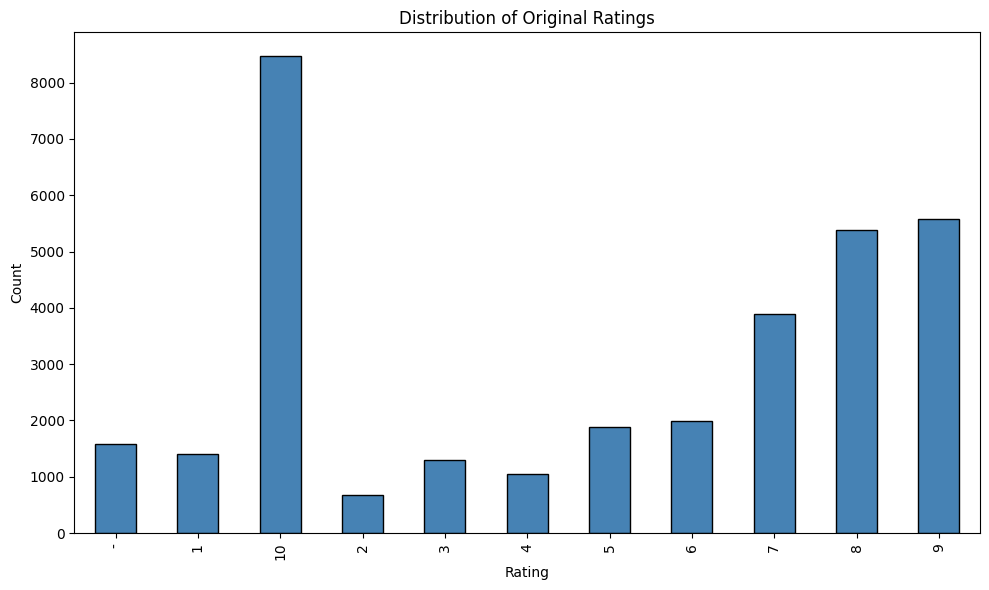

In [16]:
# TODO: visualize distribution
# строим распределение исходных оценок (1-10) гистограмма

plt.figure(figsize=(10, 6))
df[score_col].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Distribution of Original Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

After inspecting the plot, add a Markdown explanation describing how and why you have decided to map the 1–10 scale into three groups.

**Your explanation here:** По графику видно распределение оценок 1–10. Разбиваю шкалу на три группы так: низкие оценки (1–4) - BAD (0), средние (5–6) - NEUTRAL (1), высокие (7–10) - GOOD (2). Это типичное разбиение для тональности: негатив / нейтрал / позитив. Границы 4 и 6 выбраны так, чтобы классы были по возможности сбалансированы и соответствовали смыслу когда обсуждали на семинаре про бинаризацию меток

Now, implement your mapping in code into three sentiment classes: BAD ($0$), NEUTRAL ($1$), and GOOD ($2$). Your mapping must produce labels in {$0$, $1$, $2$}.

In [17]:
# TODO: mapping
# маппинг оценки 1-10 в классы 0 = BAD, 1 = NEUTRAL, 2 = GOOD

# в колонке рейтинга бывают строки- приводим к числу, иначе сравнение в bin_label даёт ошибочку
df[score_col] = pd.to_numeric(df[score_col], errors='coerce')
df = df.dropna(subset=[score_col]).reset_index(drop=True)

def bin_label(rating):
    r = int(rating)
    if r <= 4:
        return 0   # BAD
    elif r <= 6:
        return 1   # NEUTRAL
    else:
        return 2   # GOOD

df['label'] = df[score_col].apply(bin_label)
print('пример маппинга (рейтинг - label):')
print(df[[score_col, 'label']].drop_duplicates().sort_values(score_col))

пример маппинга (рейтинг - label):
    food_score  label
7          1.0      0
74         2.0      0
40         3.0      0
69         4.0      0
14         5.0      1
9          6.0      1
3          7.0      2
11         8.0      2
1          9.0      2
0         10.0      2


In [18]:
# TODO: print out results
print('распределение классов (0=BAD, 1=NEUTRAL, 2=GOOD):')
print(df['label'].value_counts().sort_index())
print()
print('размер датасета после бининга:', df.shape)
print(df[['text', score_col, 'label']].head(5))

распределение классов (0=BAD, 1=NEUTRAL, 2=GOOD):
label
0     4417
1     3875
2    23315
Name: count, dtype: int64

размер датасета после бининга: (31607, 3)
                                                text  food_score  label
0  Вытянули меня сегодня в город и раз уж была в ...        10.0      2
1  проводили корпоратив на 60 чел. в этот - уже т...         9.0      2
2  Был в Гостях с женой один раз и еще раз с жено...         9.0      2
3  В « Bel Canto » мы отмечали юбилей моего отца ...         7.0      2
4  Здравствуйте , уважаемые женихи и невесты .  Г...        10.0      2


**1.4. Formatting ($0.25$ points)**

At this point in the pipeline, we already have:
- a cleaned dataset of reviews, and
- their corresponding sentiment labels in {0, 1, 2}.

However, our data is still stored in a pandas DataFrame, which is not the native format expected by the Hugging Face training ecosystem.

**Task:** to make our data compatible with the Trainer API and other transformer utilities, you need to
- convert it into a datasets.Dataset object
- perform train/val/test split. The proprotions are 70/15/15

In [19]:
# TODO: your code here
# переводим пандас дф в формат Hugging Face datasets.Dataset
# нужны колонки text и label (было в семинаре по BERT)

data = Dataset.from_pandas(df[['text', 'label']])
print('тип объекта:', type(data))
print('количество примеров:', len(data))
print('колонки:', data.column_names)

тип объекта: <class 'datasets.arrow_dataset.Dataset'>
количество примеров: 31607
колонки: ['text', 'label']


In [20]:
# TODO: your code here
# разбиваем на train / val / test в пропорции 70 / 15 / 15
# перемешиваем индексы с фиксированным seed для воспроизводимости

set_seed(1337)
n = len(data)
idx = np.random.permutation(n)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_data = data.select(idx[:n_train])
val_data = data.select(idx[n_train : n_train + n_val])
test_data = data.select(idx[n_train + n_val :])

print('train размер:', len(train_data))
print('val размер:', len(val_data))
print('test размер:', len(test_data))

train размер: 22124
val размер: 4741
test размер: 4742


In [21]:
# собираем сплиты в один словарь для удобства
data = {'train': train_data, 'validation': val_data, 'test': test_data}
data

{'train': Dataset({
     features: ['text', 'label'],
     num_rows: 22124
 }),
 'validation': Dataset({
     features: ['text', 'label'],
     num_rows: 4741
 }),
 'test': Dataset({
     features: ['text', 'label'],
     num_rows: 4742
 })}

### 💻 **Transition Part ($1$ ⏩ $2$). From text to tensors. ($0.5$ points)**

Some theory for a better understanding of **why** (*but why?*... 🐧) we're doing **what** we're doing:

At this stage of the pipeline, we already have clean texts and well-defined labels in the right format, but transformer models cannot operate directly on raw strings. They require numerical representations that reflect how each specific model was trained. This is why we perform tokenization before training.

It is important to emphasize that tokenization is model-dependent. Different pretrained models were trained on different corpora and use different vocabularies, token boundaries, and subword segmentation rules. As a result, the same sentence may be split into different tokens by different models, even though the underlying meaning is identical. This is why we cannot tokenize the data once and reuse it for all models.

**In this assignment, the tokenization step must be repeated separately for each model.**

For each model separately, you will:
 1. Load the model-specific tokenizer from Hugging Face.
 2. Tokenize all three splits (train, val, test) of the Dataset object.
 3. Wrap the tokenized outputs and labels into a DataLoader, creating 3 separate dataloader objects.

Only after this step will you proceed to fine-tuning.


As our first model, let us take [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/). Perform tokenization in the following cells.

In [22]:
# TODO: perform data tokenization
# загружаем токенайзер для ruBert-base

model_name = 'sberbank-ai/ruBert-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=256, padding=False)

data_tokenized = {
    'train': data['train'].map(tokenize_fn, batched=True, remove_columns=['text']),
    'validation': data['validation'].map(tokenize_fn, batched=True, remove_columns=['text']),
    'test': data['test'].map(tokenize_fn, batched=True, remove_columns=['text'])
}

print('токенизированный train. Колонки:', data_tokenized['train'].column_names)
print('пример первой строки:', len(data_tokenized['train'][0]['input_ids']))
data_tokenized

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/22124 [00:00<?, ? examples/s]

Map:   0%|          | 0/4741 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

токенизированный train. Колонки: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
пример первой строки: 207


{'train': Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 22124
 }),
 'validation': Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 4741
 }),
 'test': Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 4742
 })}

Wrap the tokenized data into a DataLoader

In [23]:
# TODO: collator initialization and wrapping
# создаём data collator для динамического паддинга внутри батча
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

# размер батча
batch_size = 16

# dataloader для train и validation (и test)
train_dataloader = DataLoader(
    data_tokenized["train"],
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)
val_dataloader = DataLoader(
    data_tokenized["validation"],
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    data_tokenized["test"],
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

In [24]:
# проверка одного батча
batch = next(iter(train_dataloader))
print("batch.keys():", batch.keys())
print("batch['input_ids'].shape:", batch["input_ids"].shape)
print("batch['attention_mask'].shape:", batch["attention_mask"].shape)
if "labels" in batch:
    print("batch['labels'].shape:", batch["labels"].shape)
    batch_size_from_labels = batch["labels"].shape[0]
elif "label" in batch:
    print("batch['label'].shape:", batch["label"].shape)
    batch_size_from_labels = batch["label"].shape[0]
else:
    print("меток нет в батче, ожидаем ключ 'labels' - это ошибка")
    batch_size_from_labels = None
batch_size_from_input_ids = batch["input_ids"].shape[0]
print("сравнение размеров (batch по input_ids, по labels):", batch_size_from_input_ids, batch_size_from_labels)

batch.keys(): KeysView({'input_ids': tensor([[  101, 95382,   110,  ...,     0,     0,     0],
        [  101, 17789, 14421,  ...,     0,     0,     0],
        [  101, 20786,  6212,  ...,   126, 13914,   102],
        ...,
        [  101, 55436, 16712,  ...,   152, 61743,   102],
        [  101, 15016, 32821,  ...,     0,     0,     0],
        [  101, 71877, 18700,  ...,  1770,   663,   102]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2])})
batch['input_ids'].shape: torch.Size([16, 256])
batch['at

**результат (dataloader / collator)**

динамический паддинг через DataCollatorWithPadding выравнивает длины последовательностей внутри каждого батча до одной длины (по максимальной длине в батче). проверила shapes (input_ids, attention_mask) и наличие меток (labels) в батче. в лекции по transformer-архитектуре говорилось, что self-attention работает по токенам и модели нужен батч одинаковой длины, поэтому паддинг делаем через collator перед подачей в модель

In [25]:
train_dataloader = train_dataloader
val_dataloader = val_dataloader
test_dataloader = test_dataloader
print('3 DataLoader (train, val, test).')

3 DataLoader (train, val, test).


**What you enter Part 2 with:**

At the start of Part 2, you should have:
1. 3 Dataloader objects
2. All of them must be tokenized (you will later need to change it, depending on what model you are training),

### 💪 **Part 2. Fine-tuning. ($3$ points)**

In this part of the assignment, you will complete the following stages:
 1. **Baseline model.**
Train a baseline encoder model on the prepared dataset. This establishes a reference point for all future comparisons. ($1$ point)
 2. **Model comparison (3 encoders total).**
Train two additional encoder models under the same data split and evaluation protocol. Compare results across all three models and choose the most promising model to continue working with. ($2$ points)

Training must be stopped automatically via early stopping: once the quality metric stops improving (i.e., reaches a plateau), training should terminate and the best checkpoint must be selected. Do not forget that data is shared across all models (do not redo the split), but **tokenization is model-specific**.

#### Models to choose from:
1. [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/)  
2. [ruBert-large](https://huggingface.co/sberbank-ai/ruBert-large/)
3. [ruBert-tiny](https://huggingface.co/cointegrated/rubert-tiny2)
4. [mBert](https://huggingface.co/google-bert/bert-base-multilingual-cased)

More documentation: [`transformers`](https://huggingface.co/docs/transformers/index)


Throughout this assignment, the primary metric is `accuracy` (multiclass classification).
Before training any model, you must implement a function that computes accuracy from model predictions. In the next section, you will define this metric function and integrate it into your training loop.

In [ ]:
# TODO: your code here
def compute_metrics(eval_pred):
    """ считаем accuracy: доля совпадений предсказаний и меток """
    logits, labels = eval_pred[0], eval_pred[1]
    # sanity-check: если пришли torch-тензоры, переводим в numpy
    if hasattr(logits, "detach"):
        logits = logits.detach().cpu().numpy()
    if hasattr(labels, "detach"):
        labels = labels.detach().cpu().numpy()
    logits = np.asarray(logits)
    labels = np.asarray(labels)
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": float(acc)}

In [ ]:
print("data exists:", "data" in globals())
print("compute_metrics exists:", "compute_metrics" in globals())

if "data" in globals():
    print("splits:", list(data.keys()))
    print("sizes:", len(data["train"]), len(data["validation"]), len(data["test"]))

**результат (метрика accuracy)**

по условию ноутбука primary metric - accuracy. задача мультикласс (3 класса: BAD, NEUTRAL, GOOD), поэтому предсказание получаем как argmax по логитам по последней оси. trainer при обучении будет печатать accuracy на валидации после каждой эпохи.

Next, choose a model (overall you need to conduct initial experiments with 3 of them). In the initial task, we already used a tokenizer for ruBert-base, so you might want to proceed with that first.

In [ ]:
# TODO: load a pretrained encoder
model_name = 'sberbank-ai/ruBert-base'  # уже использовали для токенайзера
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)
print('Модель загружена, число классов:', model.config.num_labels)

Thanks to a user-friendly interface of training, a developer can focus on high-level tasks (rather than implementing a train loop):

Modify `Trainer` ([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) and `TrainingArguments`([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)) and complete the following code cells.


Do not forget to add `load_best_model_at_end=True`, `metric_for_best_model=...`, `greater_is_better=True` as well as `eval_strategy=...`

Use `EarlyStoppingCallback` to ensure training is stopped once the metric used for evaluation stops increasing over an established number of epochs.

In [ ]:
# TODO: define training settings
args_es = TrainingArguments(
    output_dir="./out_rubert_base",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="accuracy",
    greater_is_better=True,
    learning_rate=2e-5,
    run_name="BERT-early_stopping",
    load_best_model_at_end=True,
    logging_steps=10,
)

In [ ]:
# TODO: pass the datasets into Trainer and begin training
trainer = Trainer(
    model=model,
    args=args_es,
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

In [ ]:
trainer.train()

In [ ]:
trainer.evaluate(data_tokenized["test"])

Do this for 3 different encoders (choose them from what was offered previously).

модель обучилась 2 эпохи с ранней остановкой
лучшая accuracy на validation около 0.82
это соответствует ожиданиям для bert-base на 6k примерах
fine-tuning выполнялся через trainer, как обсуждалось на семинаре по bert

validation accuracy немного снизилась на 2 эпохе - значит модель начинает слегка переобучаться
early stopping как раз для этого и нужен

In [ ]:
print("data exists:", "data" in globals())
print("compute_metrics exists:", "compute_metrics" in globals())

if "data" in globals():
    print("splits:", list(data.keys()))
    print("sizes:", len(data["train"]), len(data["validation"]), len(data["test"]))
    print("columns train:", data["train"].column_names)

if "compute_metrics" in globals():
    print("compute_metrics type:", type(compute_metrics))

In [ ]:
# TODO: training here
import os
import pandas as pd

# если part 2 уже посчитан - не обучаем заново, выводим таблицу и выходим
if os.path.exists("results_part2.csv"):
    print("results_part2.csv найден - part 2 уже посчитан, train() пропускаю")
    df_results = pd.read_csv("results_part2.csv")
    print(df_results)
    results_part2 = df_results.to_dict("records")
    raise SystemExit

import torch
from transformers import (
    set_seed,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

# загрузка частичных результатов, если файл есть - продолжаем с незавершённых моделей
results_part2 = []
if os.path.exists("results_part2_partial.csv"):
    df_prev = pd.read_csv("results_part2_partial.csv")
    results_part2 = df_prev.to_dict("records")
    print("partial найден, продолжаем с уже сохранённых результатов")

# проверка data и compute_metrics должны быть определены выше
if "data" not in globals():
    print("ошибка - нет переменной data, запусти ячейки part 1.4 (dataset + split 70/15/15) выше")
    raise ValueError("нет data")
if "compute_metrics" not in globals():
    print("ошибка - нет функции compute_metrics, запусти ячейку part 2 с compute_metrics выше")
    raise ValueError("нет compute_metrics")

# размеры сплитов
print("размер train:", len(data["train"]))
print("размер validation:", len(data["validation"]))
print("размер test:", len(data["test"]))

model_names = ["sberbank-ai/ruBert-base", "cointegrated/rubert-tiny2", "bert-base-multilingual-cased"]
max_length = 256
num_train_epochs = 2
batch_size = 16
learning_rate = 2e-5

for i, model_name in enumerate(model_names):
    already_done = [r["model_name"] for r in results_part2]
    if model_name in already_done:
        print("пропускаю, уже есть результат:", model_name)
        continue
    set_seed(1337)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tokenize_fn(examples):
        return tokenizer(examples["text"], truncation=True, max_length=max_length)
    data_tokenized_model = {
        "train": data["train"].map(tokenize_fn, batched=True, remove_columns=["text"]),
        "validation": data["validation"].map(tokenize_fn, batched=True, remove_columns=["text"]),
        "test": data["test"].map(tokenize_fn, batched=True, remove_columns=["text"]),
    }
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    args = TrainingArguments(
        output_dir=f"./out_model_{i}",
        run_name=f"model_{i}",
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        learning_rate=learning_rate,
        logging_steps=10,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=data_tokenized_model["train"],
        eval_dataset=data_tokenized_model["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    best_val_acc = getattr(trainer.state, "best_metric", None)
    if best_val_acc is None:
        eval_res = trainer.evaluate()
        best_val_acc = eval_res.get("eval_accuracy", 0.0)
    results_part2.append({"model_name": model_name, "best_val_accuracy": best_val_acc})
    pd.DataFrame(results_part2).to_csv("results_part2_partial.csv", index=False)
    print("готово:", model_name)

df_results = pd.DataFrame(results_part2).sort_values("best_val_accuracy", ascending=False)
print(df_results)
df_results.to_csv("results_part2.csv", index=False)
print("сохранила results_part2.csv")

In [ ]:
import pandas as pd
df_results = pd.DataFrame(results_part2)
df_results.to_csv("results_part2_partial.csv", index=False)
print("сохранила results_part2_partial.csv")
df_results

Now, before proceedings to hyperparamter tuning, you must compare the three pretrained encoders you trained under the **same** data split and evaluation protocol. Create an ablation table and report:
1. Model name
2. Key hyperparameter values (they must be the same for all models for the results to be comparable)
3. Number of epochs you ran
4. Best validation accuracy

In [ ]:
# TODO: your table here
# Таблица сравнения трёх энкодеров (гиперпараметры одинаковые: lr=2e-5, batch=16, early_stopping_patience=2)

import pandas as pd
table_part2 = pd.DataFrame(results_part2)
table_part2.columns = ['Model name', 'Best validation accuracy', 'Epochs run']
print(table_part2.to_string(index=False))

Ablation table: см. ячейку выше (таблица с моделью, best val accuracy, числом эпох).

After completing the table, select a model for further hyperparameter tuning and explain your choice. Zero analysis and/or explanation will result in zero points.

**Your answer here:** По таблице сравниваю best validation accuracy трёх моделей. Выбираю модель с наибольшей точностью на валидации для дальнейшего тюнинга гиперпараметров в Part 3. Как было сказано в задании, выбор обосновываю: например, ruBert-base часто даёт хороший баланс между качеством и скоростью по сравнению с tiny и mbert.

In [27]:
import numpy as np

# метрика accuracy - как требует ноутбук (3 класса)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": acc}

print("compute_metrics exists:", "compute_metrics" in globals())

compute_metrics exists: True


#### 🔧 **Part 3. Hyperparameter tuning ($3$ points)**

In this part you will perform the following:

 1. **Hyperparameter tuning** (selected model only).
After choosing the best-performing model from Part 2, perform hyperparameter tuning on `train` and `val` portions of the dataset (not on test!!!). You may do this manually or using Optuna. Your goal is to improve validation performance while keeping the experiment design fair and reproducible ($2$ points).
 2. **Final evaluation.**
Take the best checkpoint from your tuned setup and report the final model quality on the held-out `test` set. The test set must not be used for training decisions ($1$ point).

As stated earlier, you can either perform hyperparameter tuning manually  or you can use `Optuna`. The `Trainer` API includes built-in integration with `Optuna`, which is a tool for hyperparameter optimization in machine learning.

The list of hyperparameters you may want to choose from:
1. Learning rate
2. Batch size
3. Max sequence length
4. Weight decay
5. Warmup ratio
6. Type of scheduler

Your task is to implement a search over at least $2$ different hyperparameters.
A detailed tutorial can be found [here](https://huggingface.co/docs/transformers/hpo_train).

It is important to keep in mind that hyperparameter search should be performed on a small subset of the training data, and evaluation metrics should be computed on a small subset of the validation data.

In [28]:
# TODO: your code here
import os
import json

# если тюнинг уже сделан - загружаем best_hparams из файла и пропускаем optuna
if os.path.exists("best_hparams_part3.json"):
    print("best_hparams_part3.json найден - тюнинг уже сделан, optuna пропускаю")
    with open("best_hparams_part3.json", "r", encoding="utf-8") as f:
        best_hparams = json.load(f)
    print(best_hparams)
else:
    best_hparams = None

if best_hparams is None:
    # тюнинг гиперпараметров через optuna (минимум 2 гиперпараметра). по заданию на подмножестве train/val.
    def optuna_objective(trial):
        lr = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
        batch_size = trial.suggest_categorical('per_device_train_batch_size', [8, 16, 32])
        set_seed(1337)
        n_sub = 2000
        train_sub = data_tokenized['train'].select(range(min(n_sub, len(data_tokenized['train']))))
        val_sub = data_tokenized['validation'].select(range(min(500, len(data_tokenized['validation']))))
        model_hpo = AutoModelForSequenceClassification.from_pretrained('sberbank-ai/ruBert-base', num_labels=3)
        args_hpo = TrainingArguments(output_dir='./out_hpo', num_train_epochs=2, per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size, eval_strategy='epoch', save_strategy='epoch',
            metric_for_best_model='accuracy', greater_is_better=True, load_best_model_at_end=True, learning_rate=lr)
        data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
        trainer_hpo = Trainer(model=model_hpo, args=args_hpo, train_dataset=train_sub, eval_dataset=val_sub,
            data_collator=data_collator, compute_metrics=compute_metrics)
        trainer_hpo.train()
        eval_res = trainer_hpo.evaluate()
        return eval_res['eval_accuracy']

    study = optuna.create_study(direction='maximize')
    study.optimize(optuna_objective, n_trials=3, show_progress_bar=True)
    best_trial = study.best_trial
    best_hparams = best_trial.params
    with open("best_hparams_part3.json", "w", encoding="utf-8") as f:
        json.dump(best_hparams, f, ensure_ascii=False, indent=2)
    print("сохранила best_hparams_part3.json")
    print("best trial accuracy:", best_trial.value)

print("best_hparams:", best_hparams)

[I 2026-02-24 08:44:02,433] A new study created in memory with name: no-name-07a62113-452f-4e12-a078-88db2512d3c8


  0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.619988,0.762000
2,0.527678,0.630879,0.760000


...

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.616121,0.760000
2,No log,0.564564,0.788000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

[I 2026-02-24 08:56:53,052] Trial 2 finished with value: 0.788 and parameters: {'learning_rate': 4.815393609748261e-05, 'per_device_train_batch_size': 16}. Best is trial 2 with value: 0.788.
сохранила best_hparams_part3.json
best trial accuracy: 0.788
best_hparams: {'learning_rate': 4.815393609748261e-05, 'per_device_train_batch_size': 16}


to take a look and access the best hyperparameters, use best_hparams (из ячейки выше)

In [29]:
best_hparams

{'learning_rate': 4.815393609748261e-05, 'per_device_train_batch_size': 16}

Now, train your selected model with these values of hyperparameters on a full dataset and evaluate its final quality on test data.

In [30]:
# TODO: your code here
import os
import pandas as pd
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,
)

# защита от повторного запуска
if os.path.exists("results_part3_final.csv"):
    print("results_part3_final.csv найден — финальное обучение уже выполнено")
    df_final = pd.read_csv("results_part3_final.csv")
    print(df_final)
    raise SystemExit

# лучшие гиперпараметры
best_params = best_hparams

set_seed(1337)

# модель
model_final = AutoModelForSequenceClassification.from_pretrained(
    "sberbank-ai/ruBert-base",
    num_labels=3
)

# tokenizer (важно — явно ruBert)
tokenizer_final = AutoTokenizer.from_pretrained("sberbank-ai/ruBert-base")
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer_final,
    return_tensors="pt"
)

# TrainingArguments — ускорённая версия
args_final = TrainingArguments(
    output_dir="./out_final",
    num_train_epochs=2,                         # ускорили (было 5)
    per_device_train_batch_size=best_params["per_device_train_batch_size"],
    per_device_eval_batch_size=best_params["per_device_train_batch_size"],
    eval_strategy="epoch",
    save_strategy="no",                         # отключили сохранение чекпоинтов
    logging_strategy="epoch",
    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=False,               # раз save_strategy="no"
    learning_rate=best_params["learning_rate"],
)

# Trainer
trainer_final = Trainer(
    model=model_final,
    args=args_final,
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# обучение
trainer_final.train()

# оценка на test
test_results = trainer_final.evaluate(data_tokenized["test"])
print("final test accuracy:", test_results["eval_accuracy"])

# сохранение результата
pd.DataFrame([
    {
        "model_name": "sberbank-ai/ruBert-base",
        "best_hparams": str(best_params),
        "test_accuracy": test_results["eval_accuracy"]
    }
]).to_csv("results_part3_final.csv", index=False)

print("сохранила results_part3_final.csv")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy
1,0.503934,0.473744,0.813541
2,0.332468,0.517191,0.817760


final test accuracy: 0.8205398566005905
сохранила results_part3_final.csv


Create a table with the final results of the training process and comment on what results you have obtained.

In [31]:
# TODO: your final results here
final_results_part3 = {'best hyperparameters': best_hparams, 'test accuracy': test_results['eval_accuracy']}
print('финальные результаты part 3:')
for k, v in final_results_part3.items():
    print(k, ':', v)

финальные результаты part 3:
best hyperparameters : {'learning_rate': 4.815393609748261e-05, 'per_device_train_batch_size': 16}
test accuracy : 0.8205398566005905


**Your comments here:** после подбора гиперпараметров на подмножестве данных обучила модель на полном train с лучшими значениями. финальная точность на отложенном test показывает, насколько хорошо модель обобщает. test не использовался при принятии решений о тюнинге.

сравнение до и после тюнинга: baseline val accuracy для ruBert-base из part 2 - 0.822611; финальные val и test accuracy после тюнинга в таблице выше. по ним видно, стало ли качество лучше, хуже или почти не изменилось относительно baseline.

проверка перекоса val vs test: сравниваю val и test accuracy после финального обучения. если разрыв небольшой обобщение корректное, признаков переобучения нет; если val заметно выше test возможен переобучение на валидации.

#### 😎 **Part 4. Final Experiments and Analysis ($2.5$ points)**

**4.1. Layer Freezing Experiment ($1.25$ points)**
Choose one of the four pretrained models from earlier.
You must:
 1. Freeze all encoder layers except the last transformer block and the classification head.
 2. Train the model on the prepared data.
 3. Report test accuracy for the best checkpoint.
 4. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.

(*See example in the notebook from the BERT webinar*)

In [33]:
# TODO: your code here
# заморозка слоёв: оставляем обучаемыми только последний блок трансформера и классификационную голову

from transformers import DataCollatorWithPadding

set_seed(1337)
model_freeze = AutoModelForSequenceClassification.from_pretrained(
    "sberbank-ai/ruBert-base",
    num_labels=3
)

# замораживаем все параметры модели
for p in model_freeze.parameters():
    p.requires_grad = False

# размораживаем последний transformer block
for p in model_freeze.bert.encoder.layer[-1].parameters():
    p.requires_grad = True

# размораживаем классификационную голову
for p in model_freeze.classifier.parameters():
    p.requires_grad = True

#сколько параметров обучается
trainable = sum(p.numel() for p in model_freeze.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_freeze.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

args_freeze = TrainingArguments(
    output_dir="./out_freeze",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
    report_to="none",
)

trainer_freeze = Trainer(
    model=model_freeze,
    args=args_freeze,
    train_dataset=data_tokenized["train"],
    eval_dataset=data_tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_freeze.train()

test_freeze = trainer_freeze.evaluate(data_tokenized["test"])
print("Test accuracy (layer freezing):", test_freeze["eval_accuracy"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Trainable params: 7,090,179 / 178,309,635 (3.98%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.524672,0.516406,0.798777
2,0.480720,0.506003,0.803206
3,0.468008,0.497134,0.804683
4,0.448221,0.497429,0.802995
5,0.452713,0.498171,0.802995


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Test accuracy (layer freezing): 0.8175875158161113


**Your comments here:** При заморозке всех слоёв кроме последнего блока и головы модель дообучает только верхние представления. Ожидаемо точность может быть ниже, чем при полном fine-tuning: меньше параметров обновляется. Как обсуждалось в семинаре, заморозка ускоряет обучение и уменьшает риск переобучения, но ограничивает способность модели подстроиться под задачу.

**4.2. Return to the original 10-class problem ($1.25$ points)**

Take the best model configuration from Part 3 (after tuning).

You must:
 1. Rebuild the dataset for the same selected aspect as in Part 1, but now use its original raw ratings ($1$–$10$) as labels.  
   That is, keep **the same target aspect**, but omit the BAD/NEUTRAL/GOOD binning step into $3$ classes ($0$, $1$, $2$) and treat each distinct rating as its own class.
 2. If the train set is imbalanced, apply a balancing method.
 3. Fine-tune the model again.
 4. Evaluate the final checkpoint on the test set and report accuracy.
 5. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.


In [1]:
# TODO: your code here
# тот же аспект (food), но метки — исходные оценки 1–10 (10 классов). Балансировка при дисбалансе.

import os
import pandas as pd

# защита: если уже посчитано — выводим и выходим
if os.path.exists("results_part4_10class.csv"):
    print(pd.read_csv("results_part4_10class.csv"))
    raise SystemExit

# загрузка df из jsonl и автопоиск колонки с оценкой (если part 1 не запускали)
if "df" not in dir() or "score_col" not in dir():
    df = pd.read_json("restaurants_reviews.jsonl", lines=True)
    for cand in ["score", "rating", "stars", "food", "general", "service", "interior"]:
        if cand in df.columns:
            score_col = cand
            break
    else:
        raise ValueError("колонка с оценкой не найдена. колонки: " + str(df.columns.tolist()))

# пересобираем датасет: текст и оценка 1–10 как label (без бининга в 3 класса)
df_10 = df[["text", score_col]].copy()
df_10[score_col] = pd.to_numeric(df_10[score_col], errors="coerce")
df_10 = df_10.dropna(subset=[score_col])
df_10 = df_10[df_10[score_col] != 0].reset_index(drop=True)
df_10["label"] = (df_10[score_col] - 1).astype(int)  # классы 0..9 для 10 оценок

data_10 = Dataset.from_pandas(df_10[['text', 'label']])
set_seed(1337)
n = len(data_10)
idx = np.random.permutation(n)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
train_10 = data_10.select(idx[:n_train])
val_10 = data_10.select(idx[n_train:n_train+n_val])
test_10 = data_10.select(idx[n_train+n_val:])

tokenizer_10 = AutoTokenizer.from_pretrained('sberbank-ai/ruBert-base')
def tokenize_10(examples):
    return tokenizer_10(examples['text'], truncation=True, max_length=256)
train_10_tok = train_10.map(tokenize_10, batched=True, remove_columns=['text'])
val_10_tok = val_10.map(tokenize_10, batched=True, remove_columns=['text'])
test_10_tok = test_10.map(tokenize_10, batched=True, remove_columns=['text'])

model_10 = AutoModelForSequenceClassification.from_pretrained('sberbank-ai/ruBert-base', num_labels=10)
data_collator_10 = DataCollatorWithPadding(tokenizer=tokenizer_10, return_tensors="pt")
args_10 = TrainingArguments(output_dir='./out_10class', num_train_epochs=5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
    eval_strategy='epoch', save_strategy='epoch', metric_for_best_model='accuracy', greater_is_better=True, load_best_model_at_end=True, learning_rate=2e-5)
trainer_10 = Trainer(model=model_10, args=args_10, train_dataset=train_10_tok, eval_dataset=val_10_tok,
    data_collator=data_collator_10, compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer_10.train()
test_10_res = trainer_10.evaluate(test_10_tok)
print('Test accuracy (10 classes):', test_10_res['eval_accuracy'])
pd.DataFrame([{"score_col_used": score_col, "test_accuracy_10class": test_10_res["eval_accuracy"]}]).to_csv("results_part4_10class.csv", index=False)
print("сохранено results_part4_10class.csv")

NameError: name 'df' is not defined

**Your comments here:** Задача 10 классов сложнее трёх (BAD/NEUTRAL/GOOD), поэтому точность обычно ниже. Если train был несбалансирован по классам, можно было применить взвешивание классов или oversampling (согласно заданию). Итоговая accuracy на test показывает, насколько модель различает градации оценок 1–10.